# 9주차_통계 기반 분석 방법론

- 다중공선성 해결과 섀플리 밸류 분석

---

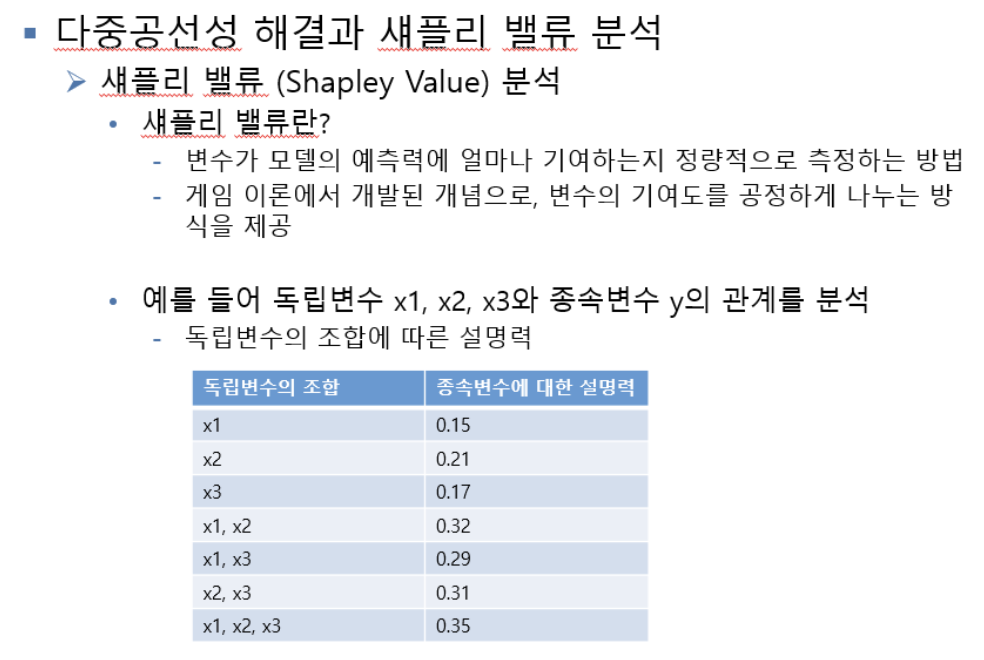

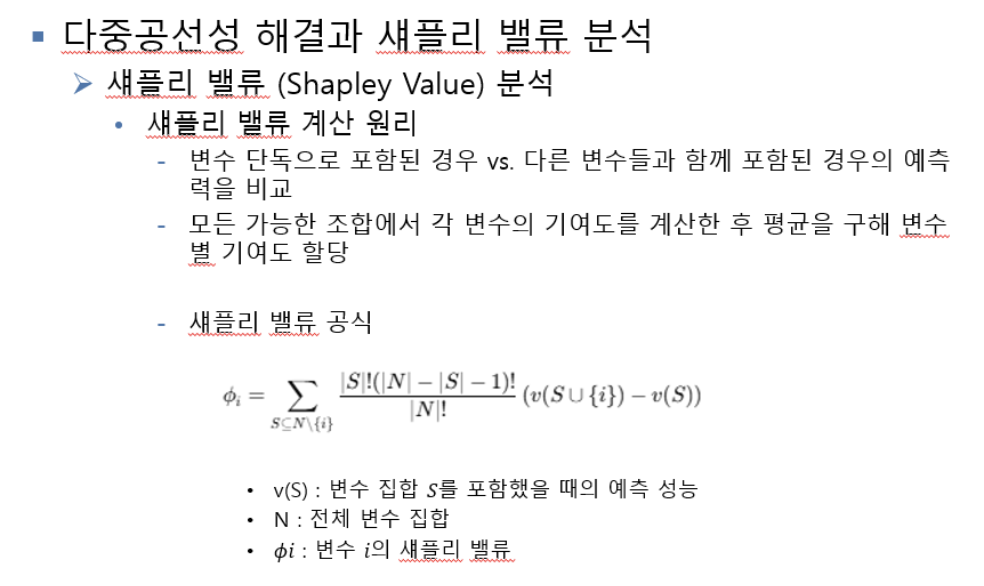

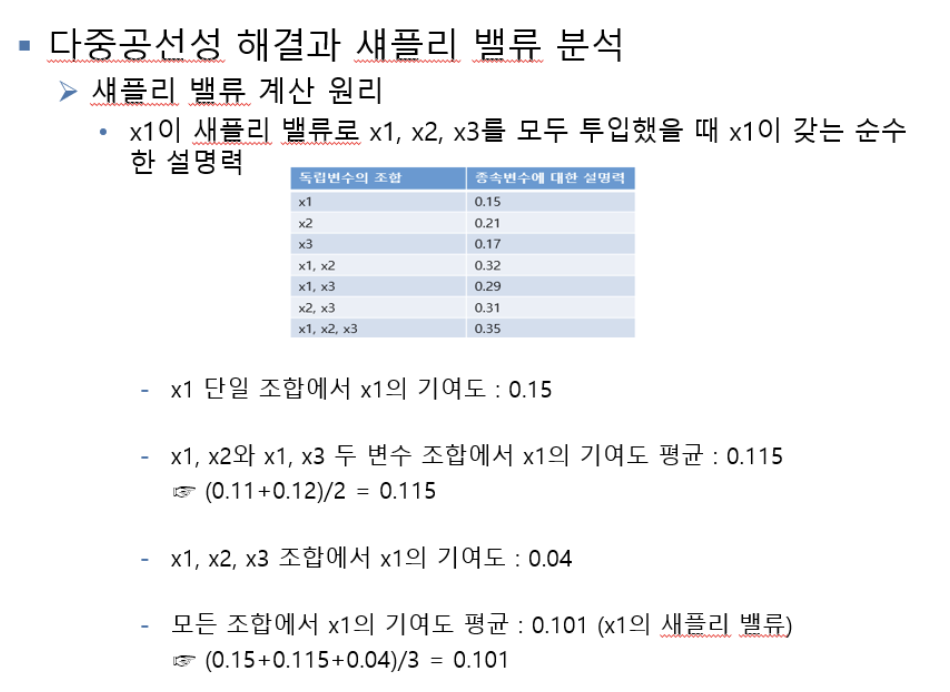

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Mac의 시스템 폰트 중 하나인 'AppleGothic'을 사용
plt.rcParams['font.family'] = 'AppleGothic'

# 마이너스(-) 기호가 깨지지 않도록 설정
mpl.rcParams['axes.unicode_minus'] = False

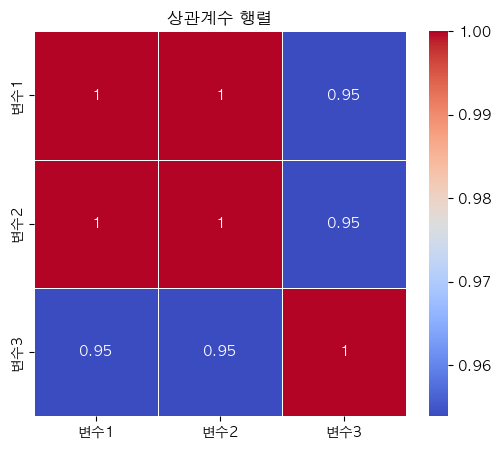

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 샘플 데이터 생성
data = pd.DataFrame({
    "변수1": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "변수2": [2, 4, 6, 8, 10, 12, 14, 16, 18, 20],
    "변수3": [5, 4, 6, 5, 7, 8, 9, 10, 12, 11]
})

# 상관계수 행렬 계산
corr_matrix = data.corr()

# 상관계수 행렬 시각화
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("상관계수 행렬")
plt.show()

In [4]:
from statsmodels.stats.outliers_influence import variance_inflation_factor  
# statsmodels 라이브러리에서 VIF(분산 팽창 요인)를 계산하는 함수 불러오기
# 이 함수는 회귀 분석 시 각 독립변수가 다른 독립변수들과 얼마나 강하게 상관되어 있는지를 수치로 나타냄

import pandas as pd  
import numpy as np  
# pandas는 데이터프레임 생성과 조작을 위한 라이브러리
# numpy는 수치 연산을 위한 라이브러리로, statsmodels 내부 연산에 필요함

# 샘플 데이터 생성
data = pd.DataFrame({
    "변수1": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "변수2": [2, 4, 6, 8, 10, 12, 14, 16, 18, 20],
    "변수3": [5, 4, 6, 5, 7, 8, 9, 10, 12, 11]
})  
# 예제용 수치형 데이터프레임을 생성함
# '변수2'는 '변수1'의 정확한 2배로 구성되어 있으므로 완벽한 선형 관계를 가짐
# 이는 심각한 다중공선성의 예시로, 회귀 분석 시 회귀계수 추정이 불안정해질 수 있음

# ✅ [이론 배경] VIF(Variance Inflation Factor)란?
# ● 하나의 독립변수를 나머지 독립변수들로 회귀했을 때 얻어지는 결정계수(R²)를 기반으로 계산함
# ● 수식: VIF = 1 / (1 - R²)
# ● 해석: R²가 클수록 해당 변수는 다른 변수들로 잘 설명됨 → VIF 값이 커짐 → 다중공선성 존재
# ● 의미: 특정 변수가 다른 변수들과 얼마나 겹치는 정보(중복된 설명력)를 가지는지를 나타내는 지표임
# ● 사용 목적: 회귀 모델 내 독립변수 간 중복 설명 문제를 사전에 진단하고 제거 혹은 차원 축소를 고려하기 위함임

# VIF 계산 함수
def calculate_vif(df):  
    # 주어진 데이터프레임(df)의 모든 열에 대해 VIF 값을 계산하는 함수 정의
    vif_data = pd.DataFrame()  
    # 결과를 저장할 빈 데이터프레임 생성

    vif_data["Feature"] = df.columns  
    # 각 변수 이름을 Feature 컬럼으로 저장

    vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]  
    # 각 변수(i번째 열)를 대상으로 VIF 값을 계산하고 VIF 컬럼에 저장
    # variance_inflation_factor(X, i)는 i번째 변수를 종속변수로 두고 나머지를 독립변수로 회귀해 R²를 구한 뒤,
    # 위 수식을 통해 해당 변수의 VIF를 반환함
    # VIF가 높을수록 해당 변수는 다른 변수들과 강한 선형 관계를 가진다는 뜻임
    # VIF가 10을 넘으면 심각한 다중공선성이 있다고 판단함

    return vif_data  
    # Feature명과 VIF 값이 담긴 데이터프레임을 반환함

# VIF 값 계산
vif_result = calculate_vif(data)  
# 위에서 정의한 함수에 샘플 데이터를 입력하여 변수 간 VIF 값을 계산함
# 결과는 각 변수의 다중공선성 수준을 수치적으로 보여주는 테이블임

print(vif_result)  
# 각 변수의 VIF 값을 출력함
# 결과를 보고 VIF가 지나치게 큰 변수가 있다면 → 모델에서 제거하거나 변수 선택/차원축소가 필요함


  Feature        VIF
0     변수1        inf
1     변수2        inf
2     변수3  26.901163


/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


### 🔢 출력 결과 요약

| 변수명 | VIF 값 | 해석 요약 |
| --- | --- | --- |
| 변수1 | `inf` | 완벽한 다중공선성 (무한대) 존재 |
| 변수2 | `inf` | 완벽한 다중공선성 (무한대) 존재 |
| 변수3 | `26.90` | 매우 심한 다중공선성 존재 |